# 语言模型


## 简介
给定文本序列 $x_1, x_2, \ldots, x_t$，语言模型估计联合概率 $p(x_1, x_2, \ldots, x_t)$。
- 做预训练模型
- 自回归生成文本
- 比较文本常见度

## 计数建模
假设序列长度为 2， 序列长度为 $N$，词元 $x$ 出现次数为 $n(x)$，$x$ 后接 $x'$ 出现次数为 $n(x, x')$。
$$p(x, x')=p(x)p(x'|x)=\cfrac{n(x)}{N} \cdot \cfrac{n(x, x')}{n(x)}=\cfrac{n(x, x')}{N}$$

## n 元语法（n-gram）
序列很长时，文本量不够大导致 $n(x_1, \ldots, x_t)$ 很小，甚至为 0。使用马尔可夫假设，只考虑前几个词元。
- 一元语法 $$p(x_1, \ldots, x_t) \approx \prod_{i=1}^{t} p(x_i)$$
- 二元语法 $$p(x_1, \ldots, x_t) \approx \prod_{i=1}^{t} p(x_i|x_{i-1})$$
- 三元语法 $$p(x_1, \ldots, x_t) \approx \prod_{i=1}^{t} p(x_i|x_{i-2}, x_{i-1})$$
- n 元语法 $$p(x_1, \ldots, x_t) \approx \prod_{i=1}^{t} p(x_i|x_{i-n+1}, \ldots, x_{i-1})$$

## 实现


In [1]:
import torch
import random
import util

查看最流行的词


In [3]:
tokens = util.tokenize(util.data.read_time_machine())
corpus = [token for line in tokens for token in line]
vocab = util.Vocab(tokens)
vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

最流行的叫“停用词”，在文本中出现频率很高，但对文本理解没有帮助。常见的停用词有“the”、“a”、“is”等。画出词频图。


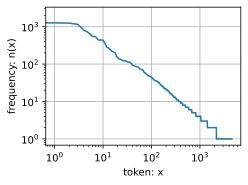

In [4]:
freqs = [freq for _, freq in vocab.token_freqs]
# 用 log-log 图画出词频分布
util.plot(freqs, xlabel='token: x', ylabel='frequency: n(x)', xscale='log', yscale='log')

看看各种 token 组合的概率


In [12]:
bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]
bigram_vocab = util.Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]

[(('of', 'the'), 309),
 (('in', 'the'), 169),
 (('i', 'had'), 130),
 (('i', 'was'), 112),
 (('and', 'the'), 109),
 (('the', 'time'), 102),
 (('it', 'was'), 99),
 (('to', 'the'), 85),
 (('as', 'i'), 78),
 (('of', 'a'), 73)]

In [13]:
qqq trigram_tokens = [pair for pair in zip(corpus[:-2], corpus[1:-1], corpus[2:])]
trigram_vocab = util.Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[(('the', 'time', 'traveller'), 59),
 (('the', 'time', 'machine'), 30),
 (('the', 'medical', 'man'), 24),
 (('it', 'seemed', 'to'), 16),
 (('it', 'was', 'a'), 15),
 (('here', 'and', 'there'), 15),
 (('seemed', 'to', 'me'), 14),
 (('i', 'did', 'not'), 14),
 (('i', 'saw', 'the'), 13),
 (('i', 'began', 'to'), 13)]

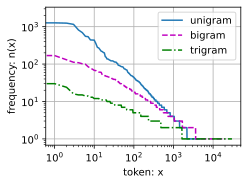

In [14]:
bigram_freqs = [freq for _, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for _, freq in trigram_vocab.token_freqs]
util.plot([freqs, bigram_freqs, trigram_freqs],
          legend=['unigram', 'bigram', 'trigram'],
          xlabel='token: x', ylabel='frequency: n(x)',
          xscale='log', yscale='log')

随机采样，每个样本是原始文本的任意子序列，生成小批量。


In [16]:
def seg_data_iter_random(corpus, batch_size, num_steps):
    """使用随机采样生成小批量子序列
    :param corpus: 文本序列
    :param batch_size: 小批量的样本数
    :param num_steps: 每个样本的时间步数
    """
    # 随机偏移量，保证每次数据切块不一样
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 子序列数量，-1 因为考虑标签
    num_subseqs = (len(corpus) - 1) // num_steps
    # 长度为 num_steps 的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 随机打乱起始索引
    random.shuffle(initial_indices)
    def data(pos):
        """根据索引返回长度为 num_steps 的序列"""
        return corpus[pos: pos + num_steps]
    num_batches = num_subseqs // batch_size # 小批量数量
    for i in range(0, batch_size * num_batches, batch_size): # 每次取 batch_size 个子序列
        initial_indices_per_batch = initial_indices[i: i + batch_size] # 每个小批量的起始索引
        X = [data(j) for j in initial_indices_per_batch] # 每个小批量的输入
        Y = [data(j + 1) for j in initial_indices_per_batch] # 每个小批量的标签（输入右移一位）
        yield torch.tensor(X), torch.tensor(Y)

测试一下


In [17]:
my_seq = list(range(30))
for X, Y in seg_data_iter_random(my_seq, batch_size=2, num_steps=5):
    print('X:', X, '\nY:', Y, '\n')

X: tensor([[24, 25, 26, 27, 28],
        [ 4,  5,  6,  7,  8]]) 
Y: tensor([[25, 26, 27, 28, 29],
        [ 5,  6,  7,  8,  9]]) 

X: tensor([[19, 20, 21, 22, 23],
        [ 9, 10, 11, 12, 13]]) 
Y: tensor([[20, 21, 22, 23, 24],
        [10, 11, 12, 13, 14]]) 



另一种算法，保证相邻的小批量在原始序列中相邻。


In [19]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):
    """使用顺序分区生成小批量子序列
    :param corpus: 文本序列
    :param batch_size: 小批量的样本数
    :param num_steps: 每个样本的时间步数
    """
    # 从随机偏移量开始划分序列，保证每次划分不一样
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size # 可整除的 token 数量
    Xs = torch.tensor(corpus[offset: offset + num_tokens]) # 输入
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens]) # 标签（输入右移一位）
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1) # 每行是一个小批量
    num_batches = Xs.shape[1] // num_steps # 小批量数量
    for i in range(0, num_steps * num_batches, num_steps): # 每次取 num_steps 个时间步
        X = Xs[:, i: i + num_steps] # 每个小批量的输入
        Y = Ys[:, i: i + num_steps] # 每个小批量的标签（输入右移一位）
        yield X, Y

In [20]:
for X, Y in seq_data_iter_sequential(my_seq, batch_size=2, num_steps=5):
    print('X:', X, '\nY:', Y, '\n')

X: tensor([[ 5,  6,  7,  8,  9],
        [17, 18, 19, 20, 21]]) 
Y: tensor([[ 6,  7,  8,  9, 10],
        [18, 19, 20, 21, 22]]) 

X: tensor([[10, 11, 12, 13, 14],
        [22, 23, 24, 25, 26]]) 
Y: tensor([[11, 12, 13, 14, 15],
        [23, 24, 25, 26, 27]]) 



包装上述两个函数


In [22]:
class SeqDataLoader:
    """加载序列数据的迭代器"""
    def __init__(self,
                 batch_size: int,
                 num_steps: int,
                 use_random_iter: bool,
                 max_tokens: int=-1):
        """初始化迭代器
        :param batch_size: 小批量的样本数
        :param num_steps: 每个样本的时间步数
        :param use_random_iter: 是否使用随机采样
        :param max_tokens: 最大 token 数量，-1 表示不限制
        """
        if use_random_iter:
            self.data_iter_fn = seg_data_iter_random
        else:
            self.data_iter_fn = seq_data_iter_sequential
        self.corpus, self.vocab = util.data.load_corpus_time_machine(max_tokens) # 读取语料库和词汇表
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)

总函数


In [ ]:
def load_data_time_machine(batch_size: int, num_steps: int, use_random_iter: bool=False, max_tokens: int=-1):
    """返回时光机器数据集的迭代器和词汇表
    :param batch_size: 小批量的样本数
    :param num_steps: 每个样本的时间步数
    :param use_random_iter: 是否使用随机采样
    :param max_tokens: 最大 token 数量，-1 表示不限制
    :return: 迭代器, 词汇表
    """
    data_iter = SeqDataLoader(batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab